# Sales Performance Analysis Dashboard

**Goal:** analyze a retail sales dataset to uncover sales trends, top-performing
products, customer purchasing behavior, and revenue growth, and turn that
analysis into KPIs and business recommendations that feed the interactive
dashboard (`dashboard/app.py`) and the business insights report.

**Contents**
1. [Load Data](#1.-Load-Data)
2. [Data Cleaning & Preprocessing](#2.-Data-Cleaning-&-Preprocessing)
3. [Exploratory Data Analysis (EDA)](#3.-Exploratory-Data-Analysis-(EDA))
4. [KPI Analysis](#4.-KPI-Analysis)
5. [Business Insights](#5.-Business-Insights)
6. [Export Cleaned Data for the Dashboard](#6.-Export-Cleaned-Data-for-the-Dashboard)

> **Note on the data:** this project ships with a synthetic-but-realistic
> retail sales dataset (`data/sales_data_raw.csv`) generated by
> `scripts/generate_data.py`, seeded with common real-world messiness
> (duplicates, missing values, inconsistent text casing, mixed date formats)
> so the cleaning section below has genuine work to do. Swap in your own
> sales export with the same column names to analyze real data.


## 1. Load Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

ACCENT = "#2563EB"
PALETTE = ["#2563EB", "#F59E0B", "#10B981", "#EF4444", "#8B5CF6", "#06B6D4"]

df = pd.read_csv("../data/sales_data_raw.csv")
print(f"Raw dataset shape: {df.shape}")
df.head()


Raw dataset shape: (10587, 17)


,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Region,Country,ProductID,ProductName,Category,Quantity,UnitPrice,Discount,Sales,Profit
0,ORD-105528,2024-12-14,2024-12-22,Standard Class,CUST-00081,Barbara Sharma,Consumer,East,South Korea,PRD-1001,Bluetooth Speaker,ELECTRONICS,3,50.46,0.0,151.38,54.37
1,ORD-102711,2024-04-20,2024-04-24,Second Class,CUST-00074,Linda Muller,corporate,East,Japan,PRD-1016,Ballpoint Pen Box,Office Supplies,2,6.42,0.2,10.27,3.01
2,ORD-100290,2024-12-02,2024-12-03,Same Day,CUST-00004,Michael Muller,Home Office,East,Japan,PRD-1042,Almond Butter Jar,Grocery,-3,10.13,0.0,-30.39,-11.06
3,ORD-102570,2024-11-19,2024-11-20,Same Day,CUST-00213,David Lee,Consumer,North,Canada,PRD-1016,Ballpoint Pen Box,OFFICE SUPPLIES,3,6.84,0.0,20.52,5.54
4,ORD-103204,2023-10-12,2023-10-18,Second Class,CUST-00777,Fatima Dubois,Consumer,North,USA,PRD-1028,Recliner Chair,Furniture,1,317.45,0.0,317.45,85.52


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10587 entries, 0 to 10586
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       10587 non-null  str    
 1   OrderDate     10587 non-null  str    
 2   ShipDate      10587 non-null  str    
 3   ShipMode      10428 non-null  str    
 4   CustomerID    10587 non-null  str    
 5   CustomerName  10481 non-null  str    
 6   Segment       10587 non-null  str    
 7   Region        10502 non-null  str    
 8   Country       10587 non-null  str    
 9   ProductID     10587 non-null  str    
 10  ProductName   10587 non-null  str    
 11  Category      10587 non-null  str    
 12  Quantity      10587 non-null  int64  
 13  UnitPrice     10587 non-null  float64
 14  Discount      10375 non-null  float64
 15  Sales         10587 non-null  float64
 16  Profit        10587 non-null  float64
dtypes: float64(4), int64(1), str(12)
memory usage: 1.4 MB


In [3]:
# A quick look at data quality problems before we clean anything
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print(f"\nExact duplicate rows: {df.duplicated().sum()}")
print(f"\nInconsistent 'Category' values: {sorted(df['Category'].unique())}")
print(f"Inconsistent 'Segment' values: {sorted(df['Segment'].unique())}")


Missing values per column:
ShipMode        159
CustomerName    106
Region           85
Discount        212
dtype: int64

Exact duplicate rows: 120

Inconsistent 'Category' values: ['CLOTHING', 'Clothing', 'ELECTRONICS', 'Electronics', 'FURNITURE', 'Furniture', 'GROCERY', 'Grocery', 'OFFICE SUPPLIES', 'Office Supplies']
Inconsistent 'Segment' values: ['  consumer  ', '  corporate  ', '  home office  ', 'Consumer', 'Corporate', 'Home Office']


## 2. Data Cleaning & Preprocessing

Steps performed:
- Strip whitespace and standardize casing on text columns
- Parse the two different date formats found in `OrderDate` into real `datetime` objects
- Drop exact duplicate rows
- Impute missing values using sensible business rules (see comments)
- Flag returns (negative quantity) and statistical outliers rather than deleting them
- Engineer helper columns used throughout the analysis (`OrderMonth`, `ProfitMargin`, etc.)


In [4]:
raw_rows = len(df)

# 2.1 Standardize text columns
text_cols = ["Segment", "Category", "Region", "ShipMode", "CustomerName", "Country", "ProductName"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df["Segment"] = df["Segment"].str.title()
df["Category"] = df["Category"].str.title()

print("Segment values after cleaning:", sorted(df["Segment"].unique()))
print("Category values after cleaning:", sorted(df["Category"].unique()))


Segment values after cleaning: ['Consumer', 'Corporate', 'Home Office']
Category values after cleaning: ['Clothing', 'Electronics', 'Furniture', 'Grocery', 'Office Supplies']


In [5]:
# 2.2 Parse the mixed date formats (yyyy-mm-dd and dd/mm/yyyy both appear)
def parse_mixed_date(s):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df["OrderDate"] = df["OrderDate"].apply(parse_mixed_date)
df["ShipDate"] = pd.to_datetime(df["ShipDate"], format="%Y-%m-%d", errors="coerce")

print(f"Unparseable OrderDate values: {df['OrderDate'].isna().sum()}")
df[["OrderDate", "ShipDate"]].head()


Unparseable OrderDate values: 0


,OrderDate,ShipDate
0,2024-12-14,2024-12-22
1,2024-04-20,2024-04-24
2,2024-12-02,2024-12-03
3,2024-11-19,2024-11-20
4,2023-10-12,2023-10-18


In [6]:
# 2.3 Drop exact duplicate rows
dupes_removed = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {dupes_removed} duplicate rows -> new shape {df.shape}")


Removed 153 duplicate rows -> new shape (10434, 17)


In [7]:
# 2.4 Handle missing values with business-sensible rules
# Region: re-derive from Country using the most common region per country
country_to_region = (
    df.dropna(subset=["Region"]).groupby("Country")["Region"]
      .agg(lambda s: s.mode().iloc[0]).to_dict()
)
df["Region"] = df.apply(
    lambda r: country_to_region.get(r["Country"], r["Region"]) if pd.isna(r["Region"]) else r["Region"],
    axis=1,
)
df["Region"] = df["Region"].fillna(df["Region"].mode().iloc[0])

# CustomerName: fill from a CustomerID -> Name lookup built from non-null rows
id_to_name = (
    df.dropna(subset=["CustomerName"]).drop_duplicates("CustomerID")
      .set_index("CustomerID")["CustomerName"].to_dict()
)
df["CustomerName"] = df.apply(
    lambda r: id_to_name.get(r["CustomerID"], "Unknown Customer") if pd.isna(r["CustomerName"]) else r["CustomerName"],
    axis=1,
)

# ShipMode: impute with the most frequent shipping mode
df["ShipMode"] = df["ShipMode"].fillna(df["ShipMode"].mode().iloc[0])

# Discount: assume 0% discount when missing
df["Discount"] = df["Discount"].fillna(0.0)

print("Remaining missing values:", int(df.isna().sum().sum()))


Remaining missing values: 0


In [8]:
# 2.5 Flag returns / cancellations (negative quantity) instead of deleting them --
# they are real business events (customer returns) and matter for a returns-rate KPI.
df["IsReturn"] = df["Quantity"] < 0
print(f"Return / cancellation line items: {int(df['IsReturn'].sum())} "
      f"({df['IsReturn'].mean()*100:.2f}% of rows)")


Return / cancellation line items: 156 (1.50% of rows)


In [9]:
# 2.6 Flag statistical outliers in Sales using the IQR method (flag, don't delete --
# large B2B orders are legitimate business and useful signal, not noise)
q1, q3 = df["Sales"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 3 * iqr
df["SalesOutlier"] = df["Sales"] > upper_bound
print(f"Sales outliers flagged (> ${upper_bound:,.0f}): {int(df['SalesOutlier'].sum())}")


Sales outliers flagged (> $961): 494


In [10]:
# 2.7 Feature engineering
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["OrderYear"] = df["OrderDate"].dt.year
df["OrderQuarter"] = df["OrderDate"].dt.to_period("Q").astype(str)
df["DayOfWeek"] = df["OrderDate"].dt.day_name()
df["ShippingDelayDays"] = (df["ShipDate"] - df["OrderDate"]).dt.days
df["ProfitMargin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)

clean_rows = len(df)
print(f"Clean dataset: {clean_rows:,} rows, {df.shape[1]} columns "
      f"(started from {raw_rows:,} raw rows)")
df.head()


Clean dataset: 10,434 rows, 25 columns (started from 10,587 raw rows)


,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Region,Country,ProductID,ProductName,Category,Quantity,UnitPrice,Discount,Sales,Profit,IsReturn,SalesOutlier,OrderMonth,OrderYear,OrderQuarter,DayOfWeek,ShippingDelayDays,ProfitMargin
0,ORD-105528,2024-12-14,2024-12-22,Standard Class,CUST-00081,Barbara Sharma,Consumer,East,South Korea,PRD-1001,Bluetooth Speaker,Electronics,3,50.46,0.0,151.38,54.37,False,False,2024-12,2024,2024Q4,Saturday,8,0.359162
1,ORD-102711,2024-04-20,2024-04-24,Second Class,CUST-00074,Linda Muller,Corporate,East,Japan,PRD-1016,Ballpoint Pen Box,Office Supplies,2,6.42,0.2,10.27,3.01,False,False,2024-04,2024,2024Q2,Saturday,4,0.293087
2,ORD-100290,2024-12-02,2024-12-03,Same Day,CUST-00004,Michael Muller,Home Office,East,Japan,PRD-1042,Almond Butter Jar,Grocery,-3,10.13,0.0,-30.39,-11.06,True,False,2024-12,2024,2024Q4,Monday,1,0.363936
3,ORD-102570,2024-11-19,2024-11-20,Same Day,CUST-00213,David Lee,Consumer,North,Canada,PRD-1016,Ballpoint Pen Box,Office Supplies,3,6.84,0.0,20.52,5.54,False,False,2024-11,2024,2024Q4,Tuesday,1,0.269981
4,ORD-103204,2023-10-12,2023-10-18,Second Class,CUST-00777,Fatima Dubois,Consumer,North,USA,PRD-1028,Recliner Chair,Furniture,1,317.45,0.0,317.45,85.52,False,False,2023-10,2023,2023Q4,Thursday,6,0.269397


In [11]:
# For most revenue/profitability analysis we exclude returns (negative quantity lines);
# they're kept in `df` for a dedicated returns-rate KPI, but analysed separately here.
sales_df = df[~df["IsReturn"]].copy()
print(f"Sales-only rows used for revenue analysis: {len(sales_df):,}")


Sales-only rows used for revenue analysis: 10,278


## 3. Exploratory Data Analysis (EDA)

### 3.1 Monthly revenue & profit trend

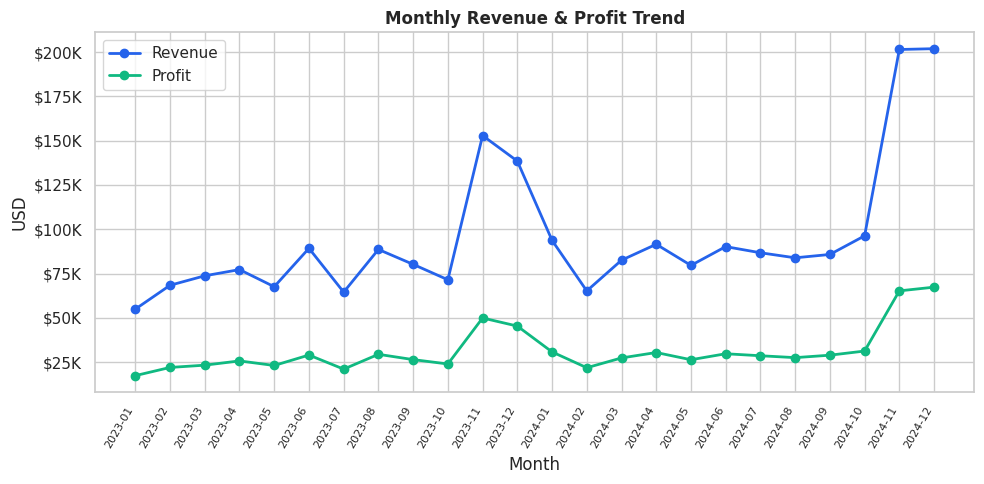

In [12]:
monthly = (
    sales_df.groupby("OrderMonth")
    .agg(Revenue=("Sales", "sum"), Profit=("Profit", "sum"))
    .reset_index()
    .sort_values("OrderMonth")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly["OrderMonth"], monthly["Revenue"], marker="o", color=ACCENT, linewidth=2, label="Revenue")
ax.plot(monthly["OrderMonth"], monthly["Profit"], marker="o", color=PALETTE[2], linewidth=2, label="Profit")
ax.set_title("Monthly Revenue & Profit Trend")
ax.set_xlabel("Month"); ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.xticks(rotation=60, ha="right", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()


### 3.2 Revenue by product category

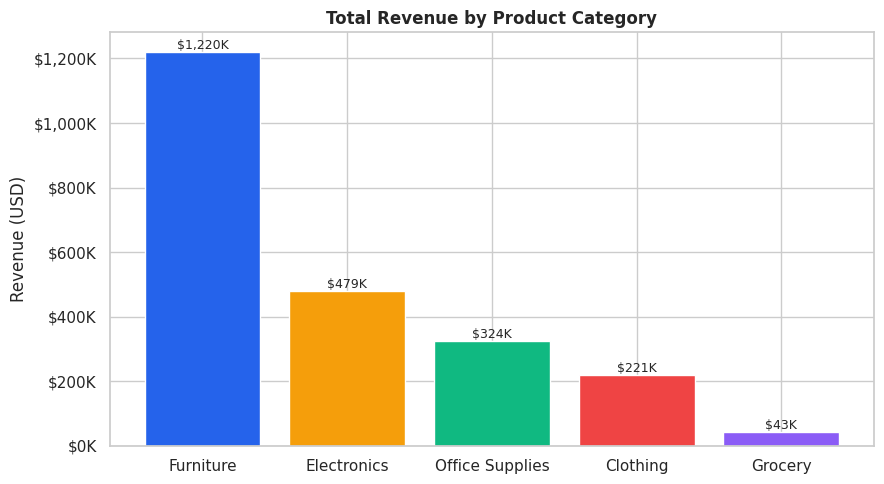

In [13]:
cat_rev = sales_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cat_rev.index, cat_rev.values, color=PALETTE[:len(cat_rev)])
ax.set_title("Total Revenue by Product Category")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
for b in bars:
    ax.annotate(f"${b.get_height()/1000:,.0f}K", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


### 3.3 Top 10 products by revenue

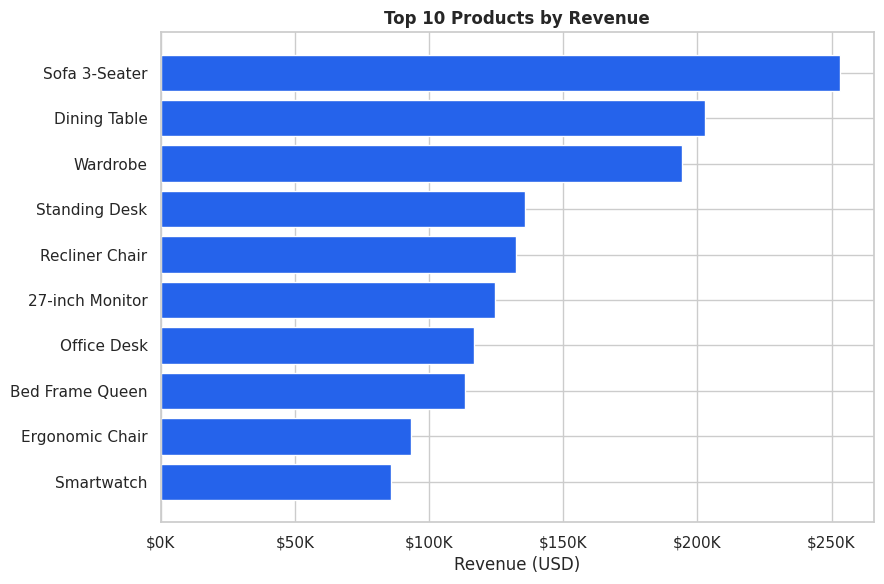

In [14]:
top_products = sales_df.groupby("ProductName")["Sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_products.index[::-1], top_products.values[::-1], color=ACCENT)
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.tight_layout()
plt.show()


### 3.4 Revenue by region

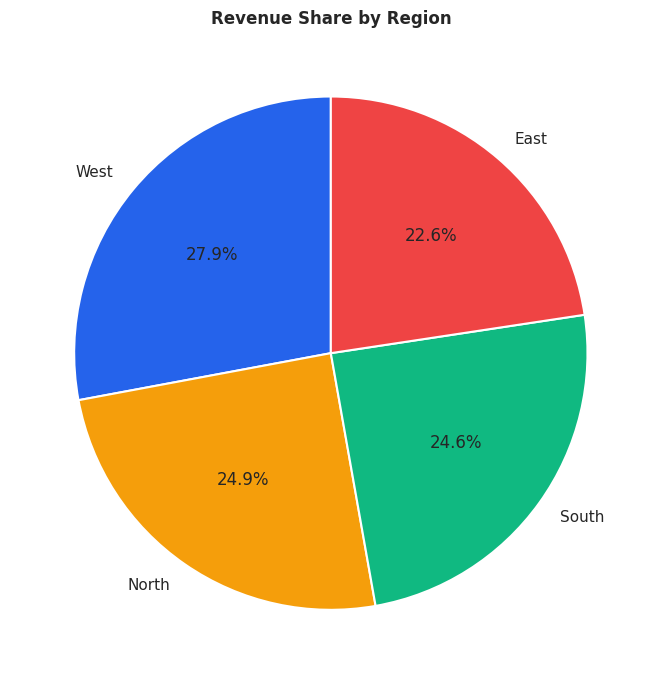

In [15]:
region_rev = sales_df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(region_rev.values, labels=region_rev.index, autopct="%1.1f%%", startangle=90,
       colors=PALETTE[:len(region_rev)], wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Revenue Share by Region")
plt.tight_layout()
plt.show()


### 3.5 Customer segment analysis

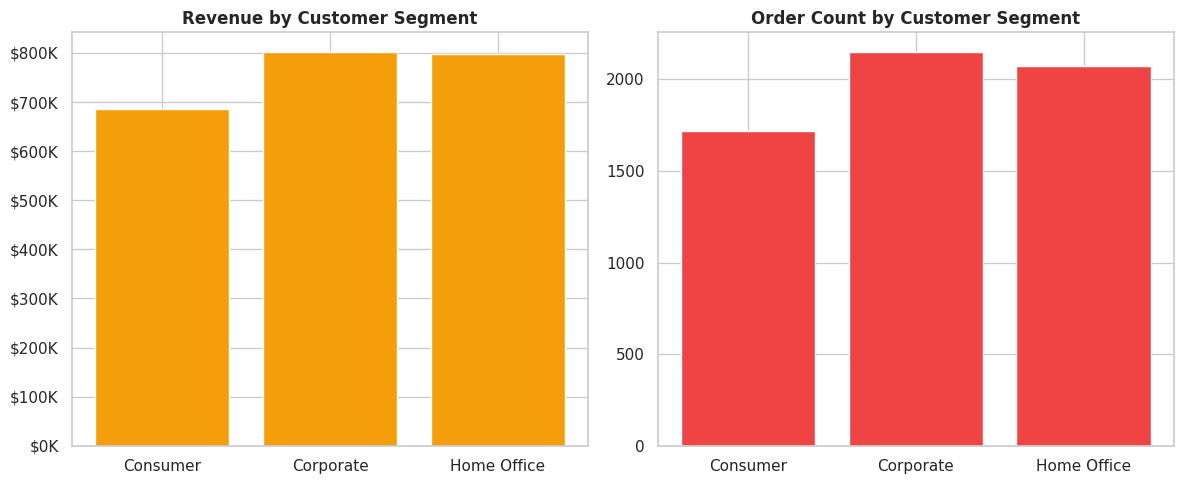

In [16]:
seg = sales_df.groupby("Segment").agg(Revenue=("Sales", "sum"), Orders=("OrderID", "nunique")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(seg["Segment"], seg["Revenue"], color=PALETTE[1])
axes[0].set_title("Revenue by Customer Segment")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
axes[1].bar(seg["Segment"], seg["Orders"], color=PALETTE[3])
axes[1].set_title("Order Count by Customer Segment")
plt.tight_layout()
plt.show()


### 3.6 Discount level vs. profit margin

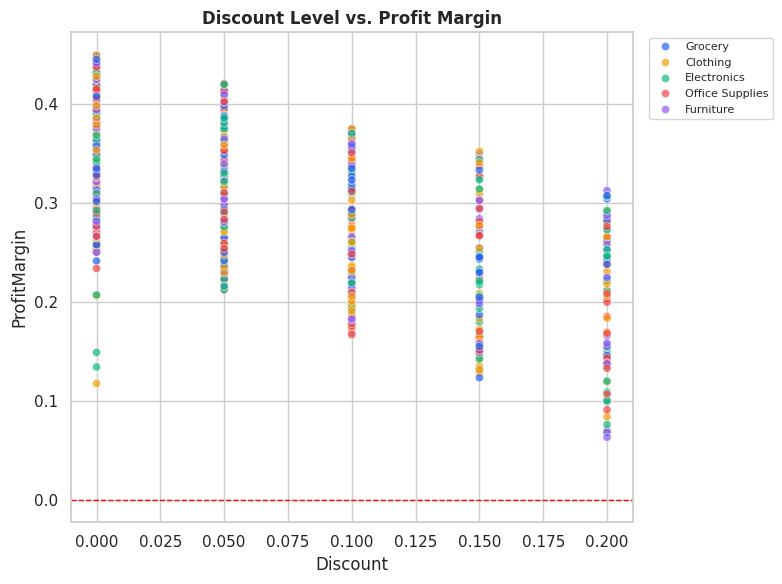

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = sales_df.sample(min(1500, len(sales_df)), random_state=42)
sns.scatterplot(data=sample, x="Discount", y="ProfitMargin", hue="Category",
                 palette=PALETTE, ax=ax, alpha=0.7, s=35)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Discount Level vs. Profit Margin")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### 3.7 Order volume by day of week

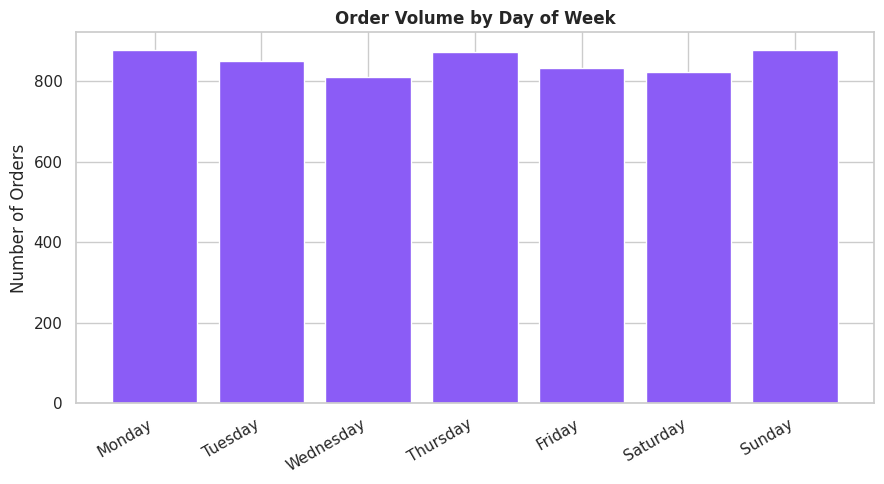

In [18]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = sales_df.groupby("DayOfWeek")["OrderID"].nunique().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dow.index, dow.values, color=PALETTE[4])
ax.set_title("Order Volume by Day of Week")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 3.8 Customer purchase frequency

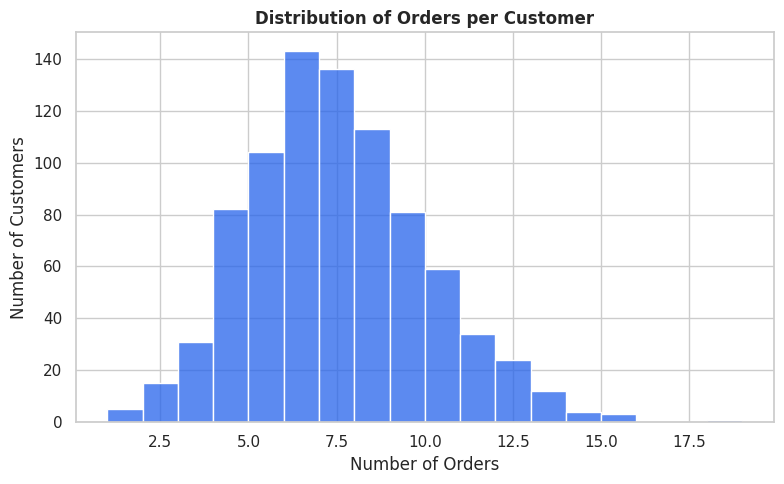

In [19]:
cust_freq = sales_df.groupby("CustomerID")["OrderID"].nunique()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(cust_freq, bins=range(1, cust_freq.max() + 2), color=ACCENT, ax=ax)
ax.set_title("Distribution of Orders per Customer")
ax.set_xlabel("Number of Orders"); ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 4. KPI Analysis

In [20]:
total_revenue = float(sales_df["Sales"].sum())
total_profit = float(sales_df["Profit"].sum())
profit_margin_pct = (total_profit / total_revenue * 100) if total_revenue else 0
total_orders = int(sales_df["OrderID"].nunique())
total_customers = int(sales_df["CustomerID"].nunique())
avg_order_value = float(sales_df.groupby("OrderID")["Sales"].sum().mean())
total_units_sold = int(sales_df["Quantity"].sum())
return_rate_pct = float(df["IsReturn"].sum() / len(df) * 100)

monthly_sorted = monthly.sort_values("OrderMonth")
mom_growth_pct = None
if len(monthly_sorted) >= 2:
    last, prev = monthly_sorted["Revenue"].iloc[-1], monthly_sorted["Revenue"].iloc[-2]
    mom_growth_pct = float((last - prev) / prev * 100) if prev else None

yearly = sales_df.groupby("OrderYear")["Sales"].sum().sort_index()
yoy_growth_pct = None
if len(yearly) >= 2:
    yoy_growth_pct = float((yearly.iloc[-1] - yearly.iloc[-2]) / yearly.iloc[-2] * 100)

orders_per_cust = sales_df.groupby("CustomerID")["OrderID"].nunique()
repeat_customer_rate_pct = float((orders_per_cust > 1).mean() * 100)

kpis = {
    "Total Revenue": f"${total_revenue:,.0f}",
    "Total Profit": f"${total_profit:,.0f}",
    "Profit Margin %": f"{profit_margin_pct:.1f}%",
    "Total Orders": f"{total_orders:,}",
    "Total Customers": f"{total_customers:,}",
    "Average Order Value": f"${avg_order_value:,.2f}",
    "Total Units Sold": f"{total_units_sold:,}",
    "Return Rate %": f"{return_rate_pct:.2f}%",
    "MoM Revenue Growth %": f"{mom_growth_pct:+.1f}%" if mom_growth_pct is not None else "n/a",
    "YoY Revenue Growth %": f"{yoy_growth_pct:+.1f}%" if yoy_growth_pct is not None else "n/a",
    "Repeat Customer Rate %": f"{repeat_customer_rate_pct:.1f}%",
    "Top Category": cat_rev.idxmax(),
    "Top Product": top_products.idxmax(),
    "Top Region": region_rev.idxmax(),
    "Best Order Day": dow.idxmax(),
}

pd.DataFrame(kpis.items(), columns=["KPI", "Value"])


,KPI,Value
0,Total Revenue,"$2,286,031"
1,Total Profit,"$751,288"
2,Profit Margin %,32.9%
3,Total Orders,"5,946"
4,Total Customers,847
5,Average Order Value,$384.47
6,Total Units Sold,"25,534"
7,Return Rate %,1.50%
8,MoM Revenue Growth %,+0.2%
9,YoY Revenue Growth %,+22.6%


## 5. Business Insights

Turning the KPIs and charts above into plain-English, decision-ready takeaways.
These same insights are exported to `outputs/insights.json` and written up in
`outputs/reports/Business_Insights_Report.pdf`.


In [21]:
top3_categories = cat_rev.head(3)
bottom_category = cat_rev.idxmin()
top3_products = top_products.head(3)
region_share = (region_rev / region_rev.sum() * 100).round(1)
seg_sorted = seg.sort_values("Revenue", ascending=False)

insights = [
    f"Total revenue across the analysis period reached ${total_revenue:,.0f} with an overall profit "
    f"margin of {profit_margin_pct:.1f}%, generating ${total_profit:,.0f} in profit.",

    f"{cat_rev.idxmax()} is the leading product category, contributing ${top3_categories.iloc[0]:,.0f} "
    f"({top3_categories.iloc[0] / total_revenue * 100:.1f}% of total revenue), followed by "
    f"{top3_categories.index[1]} and {top3_categories.index[2]}. "
    f"{bottom_category} is the lowest-performing category and is a candidate for a promotional "
    f"push or portfolio review.",

    f"The single best-selling product is '{top_products.idxmax()}', generating "
    f"${top3_products.iloc[0]:,.0f} in revenue. The top 3 products together account for "
    f"${top3_products.sum():,.0f} in revenue, indicating some concentration risk worth monitoring.",

    f"{region_rev.idxmax()} is the strongest region, driving {region_share.iloc[0]:.1f}% of total revenue.",

    f"{seg_sorted.iloc[0]['Segment']} is the highest-value customer segment by revenue "
    f"(${seg_sorted.iloc[0]['Revenue']:,.0f}), suggesting marketing and retention budget should be "
    f"weighted toward this group.",

    f"Repeat customers make up {repeat_customer_rate_pct:.1f}% of the customer base -- growing this "
    f"rate has an outsized impact on revenue stability since repeat customers are cheaper to serve "
    f"than new-customer acquisition.",

    f"{dow.idxmax()} is the peak order day of the week, useful for scheduling promotions, staffing, "
    f"and ad spend timing.",

    f"Higher discount levels (>15%) are associated with thinner or negative profit margins in the "
    f"data, so discounting strategy should be reviewed per category rather than applied uniformly.",

    f"The return rate is {return_rate_pct:.1f}% of line items -- within a normal retail range but "
    f"worth tracking over time as a leading indicator of product-quality or fulfillment issues.",
]

for i, line in enumerate(insights, 1):
    print(f"{i}. {line}\n")


1. Total revenue across the analysis period reached $2,286,031 with an overall profit margin of 32.9%, generating $751,288 in profit.

2. Furniture is the leading product category, contributing $1,219,910 (53.4% of total revenue), followed by Electronics and Office Supplies. Grocery is the lowest-performing category and is a candidate for a promotional push or portfolio review.

3. The single best-selling product is 'Sofa 3-Seater', generating $253,179 in revenue. The top 3 products together account for $650,008 in revenue, indicating some concentration risk worth monitoring.

4. West is the strongest region, driving 27.9% of total revenue.

5. Corporate is the highest-value customer segment by revenue ($801,874), suggesting marketing and retention budget should be weighted toward this group.

6. Repeat customers make up 99.4% of the customer base -- growing this rate has an outsized impact on revenue stability since repeat customers are cheaper to serve than new-customer acquisition.


## 6. Export Cleaned Data for the Dashboard

Saves the cleaned dataset, KPI summary, and insights so the Streamlit
dashboard (`dashboard/app.py`) and the PDF report generator can consume them
without re-running this notebook.


In [22]:
import os
os.makedirs("../outputs", exist_ok=True)
df.to_csv("../outputs/cleaned_sales_data.csv", index=False)

kpi_export = {
    "total_revenue": round(total_revenue, 2),
    "total_profit": round(total_profit, 2),
    "profit_margin_pct": round(profit_margin_pct, 2),
    "total_orders": total_orders,
    "total_customers": total_customers,
    "avg_order_value": round(avg_order_value, 2),
    "total_units_sold": total_units_sold,
    "return_rate_pct": round(return_rate_pct, 2),
    "mom_revenue_growth_pct": round(mom_growth_pct, 2) if mom_growth_pct is not None else None,
    "yoy_revenue_growth_pct": round(yoy_growth_pct, 2) if yoy_growth_pct is not None else None,
    "repeat_customer_rate_pct": round(repeat_customer_rate_pct, 2),
    "top_category": cat_rev.idxmax(),
    "top_product": top_products.idxmax(),
    "top_region": region_rev.idxmax(),
    "best_day_of_week": dow.idxmax(),
}
with open("../outputs/kpis.json", "w") as f:
    json.dump(kpi_export, f, indent=2)
with open("../outputs/insights.json", "w") as f:
    json.dump(insights, f, indent=2)

print("Saved: outputs/cleaned_sales_data.csv, outputs/kpis.json, outputs/insights.json")
print("\nNext step: launch the dashboard with `streamlit run dashboard/app.py` from the project root.")


Saved: outputs/cleaned_sales_data.csv, outputs/kpis.json, outputs/insights.json

Next step: launch the dashboard with `streamlit run dashboard/app.py` from the project root.
